# Tarea 1
## Contestando preguntas sobre los datos

## Desarollo
### Conexión mediante API
A través del API Free Weather, se accede al conjunto de datos de variables hidrometeorológicas. Se seleccionó una coordenada en el volcán Casitagua, y se recopilaron datos para la semana previa al día 22 de septiembre, y la semana posterior (2026-09-16 al 2026-09-29)

In [ ]:
# !pip install openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.1/229.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.4/407.4 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.7 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [ ]:
import openmeteo_requests
import os
import pandas as pd
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

In [ ]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": -0.037938271116905065,
	"longitude": -78.47467600552498,
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation_probability", "wind_direction_10m", "wind_direction_80m", "direct_radiation"],
	"models": "best_match",
	"timezone": "America/Chicago",
	"past_days": 7,
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation_probability = hourly.Variables(2).ValuesAsNumpy()
hourly_wind_direction_10m = hourly.Variables(3).ValuesAsNumpy()
hourly_wind_direction_80m = hourly.Variables(4).ValuesAsNumpy()
hourly_direct_radiation = hourly.Variables(5).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["precipitation_probability"] = hourly_precipitation_probability
hourly_data["wind_direction_10m"] = hourly_wind_direction_10m
hourly_data["wind_direction_80m"] = hourly_wind_direction_80m
hourly_data["direct_radiation"] = hourly_direct_radiation

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

Coordinates: -0.1054481565952301°N -78.56585693359375°E
Elevation: 3299.0 m asl
Timezone: b'America/Chicago'b'GMT-5'
Timezone difference to GMT+0: -18000s

Hourly data
                          date  temperature_2m  relative_humidity_2m  \
0   2026-09-16 00:00:00-05:00        8.621500             75.435112   
1   2026-09-16 01:00:00-05:00        9.121500             68.228828   
2   2026-09-16 02:00:00-05:00        7.471500             74.973083   
3   2026-09-16 03:00:00-05:00        7.671500             75.537987   
4   2026-09-16 04:00:00-05:00        7.371500             77.644638   
..                        ...             ...                   ...   
331 2026-09-29 19:00:00-05:00        9.271500             98.995178   
332 2026-09-29 20:00:00-05:00        9.171500             99.328590   
333 2026-09-29 21:00:00-05:00        9.171500             99.328590   
334 2026-09-29 22:00:00-05:00        9.171500             99.663795   
335 2026-09-29 23:00:00-05:00        9.221499     

In [ ]:
hourly_dataframe.shape

(336, 7)

In [ ]:
hourly_dataframe.head()

,date,temperature_2m,relative_humidity_2m,precipitation_probability,wind_direction_10m,wind_direction_80m,direct_radiation
0,2026-09-16 00:00:00-05:00,8.6215,75.435112,1.0,138.012863,134.090714,0.0
1,2026-09-16 01:00:00-05:00,9.1215,68.228828,0.0,126.469330,123.690094,0.0
2,2026-09-16 02:00:00-05:00,7.4715,74.973083,0.0,147.994659,137.910919,0.0
3,2026-09-16 03:00:00-05:00,7.6715,75.537987,0.0,147.994659,133.958466,0.0
4,2026-09-16 04:00:00-05:00,7.3715,77.644638,0.0,153.435013,143.841721,0.0


In [ ]:
# Connecting to Google drive
from google.colab import drive
drive.mount('/content/drive')

dir_drive = '/content/drive/MyDrive/Colab Notebooks/2_fundamentos_ciencia_datos'
# Saving the df
#hourly_dataframe.to_csv(os.path.join(dir_drive, 'datos_eda.csv'), index=False, encoding='utf-8-sig')
# Loading the df from the csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Revisión preliminar de datos

In [ ]:
hourly_dataframe.dtypes

,0
date,"datetime64[ns, America/Chicago]"
temperature_2m,float32
relative_humidity_2m,float32
precipitation_probability,float32
wind_direction_10m,float32
wind_direction_80m,float32
direct_radiation,float32


In [ ]:
hourly_dataframe.describe()
# Direct radiation measure unit: W/m²

,temperature_2m,relative_humidity_2m,precipitation_probability,wind_direction_10m,wind_direction_80m,direct_radiation
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,10.650517,84.437645,43.294643,157.709396,160.852570,117.178574
std,2.766568,17.983002,39.452511,90.064201,89.744911,191.197815
min,5.471500,33.386524,0.000000,6.008918,7.124930,0.000000
25%,8.871500,74.220879,0.750000,95.854727,92.574257,0.000000
50%,9.871500,93.038128,35.500000,135.000107,132.113312,0.000000
75%,12.084000,98.995863,85.000000,204.226086,243.435013,165.000000
max,19.321501,100.000000,100.000000,360.000000,360.000000,895.000000


In [ ]:
print("Rango temporal:", hourly_dataframe['date'].min(),
      " a ", hourly_dataframe['date'].max())

Rango temporal: 2026-09-16 00:00:00-05:00  a  2026-09-29 23:00:00-05:00


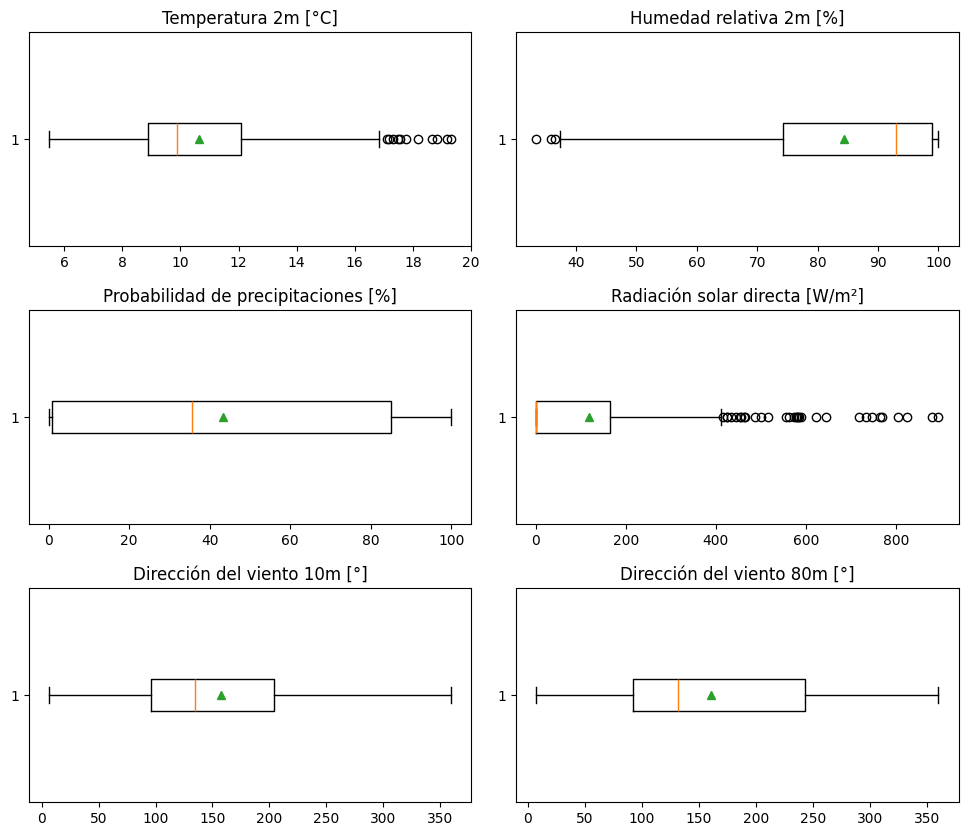

In [ ]:
# Boxplots
fig, axs = plt.subplots(3, 2, figsize=(12, 10))
# 1. Temperatura 2m [°C]
axs[0, 0].boxplot(hourly_dataframe['temperature_2m'], orientation='horizontal', showmeans=True)
axs[0, 0].set_title('Temperatura 2m [°C]')
# 2. Humedad relativa 2m [%]
axs[0, 1].boxplot(hourly_dataframe['relative_humidity_2m'], orientation='horizontal', showmeans=True)
axs[0, 1].set_title('Humedad relativa 2m [%]')
# 3. Probabilidad de precipitaciones [%]
axs[1, 0].boxplot(hourly_dataframe['precipitation_probability'], orientation='horizontal', showmeans=True)
axs[1, 0].set_title('Probabilidad de precipitaciones [%]')
# 4. Radiación solar directa [W/m²]
axs[1, 1].boxplot(hourly_dataframe['direct_radiation'], orientation='horizontal', showmeans=True)
axs[1, 1].set_title('Radiación solar directa [W/m²]')
# 5. Dirección del viento 10m [°]
axs[2, 0].boxplot(hourly_dataframe['wind_direction_10m'], orientation='horizontal', showmeans=True)
axs[2, 0].set_title('Dirección del viento 10m [°]')
# 6. Dirección del viento 80m [°]
axs[2, 1].boxplot(hourly_dataframe['wind_direction_80m'], orientation='horizontal', showmeans=True)
axs[2, 1].set_title('Dirección del viento 80m [°]')
plt.subplots_adjust(hspace=0.3, wspace=0.1)
plt.show()

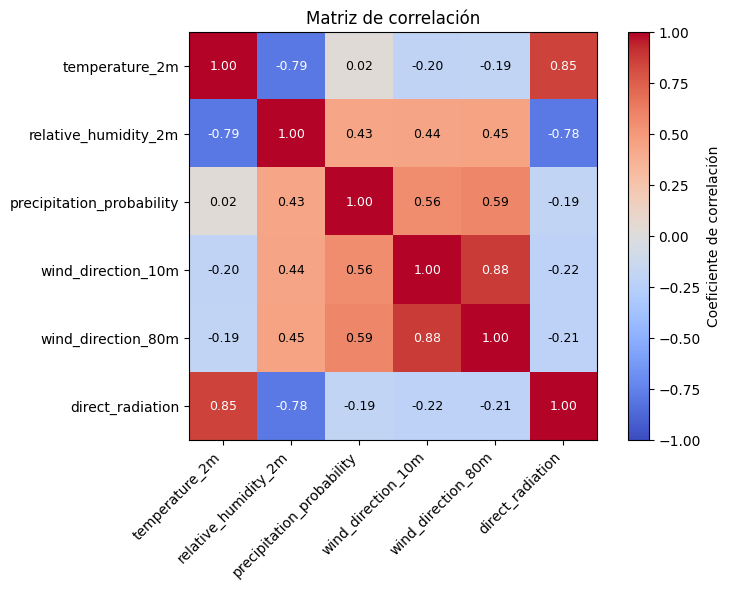

In [ ]:
# Correlación (usa method='spearman' si las variables no son normales)
var_corr = ['temperature_2m',	'relative_humidity_2m',
            'precipitation_probability',	'wind_direction_10m',
            'wind_direction_80m',	'direct_radiation']
corr = hourly_dataframe[var_corr].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))

# Mapa de color centrado en 0 (equivale a center=0 de seaborn)
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
# Barra de color
fig.colorbar(im, ax=ax, label='Coeficiente de correlación')
# Etiquetas de los ejes
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
# Valores dentro de cada celda (equivale a annot=True, fmt='.2f')
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        color_texto = 'white' if abs(valor) > 0.6 else 'black'   # contraste en celdas oscuras
        ax.text(j, i, f'{valor:.2f}', ha='center', va='center',
                color=color_texto, fontsize=9)
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

### Planteando las preguntas

1.   ¿Cuál es la diferencia entre las medias de datos de predicción y los observados?
2.   ¿Cuál es la dirección predominante que tiene el viento en el punto observado?
3.   ¿Existe un comportamiento observable entre probabilidad de precipitación y de la radiación solar directa que permita plantear una hipótesis sobre la relación que existe entre estos factores?



In [ ]:
# Divide the df
df_obs = hourly_dataframe[hourly_dataframe['date'] < '2026-09-23']
df_prd = hourly_dataframe[hourly_dataframe['date'] >= '2026-09-23']

In [ ]:
df_obs.describe()

,temperature_2m,relative_humidity_2m,precipitation_probability,wind_direction_10m,wind_direction_80m,direct_radiation
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,11.134892,75.942406,23.005953,134.125656,131.220261,149.541672
std,3.446465,19.566339,33.128586,76.976868,73.465446,234.689590
min,5.471500,33.386524,0.000000,6.008918,7.124930,0.000000
25%,8.571500,59.728701,0.000000,85.193277,87.550180,0.000000
50%,10.446500,79.496960,1.000000,126.313805,120.497543,0.000000
75%,13.596500,93.931944,38.250000,153.435013,145.082123,238.750000
max,19.321501,100.000000,100.000000,360.000000,360.000000,895.000000


In [ ]:
df_prd.describe()

,temperature_2m,relative_humidity_2m,precipitation_probability,wind_direction_10m,wind_direction_80m,direct_radiation
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,10.166142,92.932884,63.583332,181.293152,190.484879,84.815475
std,1.733045,10.984942,34.592297,96.058365,94.829819,127.064545
min,7.621500,54.740948,0.000000,9.462248,19.653913,0.000000
25%,8.921500,91.338463,32.750000,106.278580,99.129192,0.000000
50%,9.471499,98.325645,71.000000,151.845108,201.959549,0.000000
75%,11.109000,99.660679,100.000000,275.938225,277.202744,138.500000
max,15.171500,100.000000,100.000000,353.659912,360.000000,556.000000


**Respuesta pregunta 1**

In [ ]:
# Q1 Answer:
df1 = df_obs.describe()
df2 = df_prd.describe()
print("Pregunta 1\n\n",
      "Diferencias de medias entre el grupo observado y la predicción:\n", df1.loc['mean'] - df2.loc['mean'])

Pregunta 1

 Diferencias de medias entre el grupo observado y la predicción:
 temperature_2m                0.968750
relative_humidity_2m        -16.990479
precipitation_probability   -40.577379
wind_direction_10m          -47.167496
wind_direction_80m          -59.264618
direct_radiation             64.726196
Name: mean, dtype: float64


/tmp/ipykernel_677/1017976713.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(v)}%' for v in ax.get_yticks()])


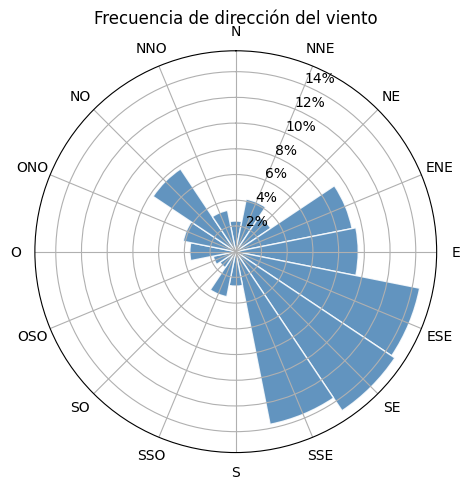

In [ ]:
# Round histogram
# Wind directions without NaN
direccion = hourly_dataframe['wind_direction_10m'].dropna()
# 16 "bins" of 22.5°, moved by half a sector so North centers on 0°
n_sectores = 16
ancho = 360 / n_sectores
dir_desplazada = (direccion + ancho / 2) % 360
conteos, bordes = np.histogram(dir_desplazada, bins=n_sectores, range=(0, 360))
# Freq
frecuencia = conteos / conteos.sum() * 100
# Center angle of each bin (rads)
angulos = np.deg2rad(np.arange(0, 360, ancho))
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': 'polar'})
ax.bar(angulos, frecuencia, width=np.deg2rad(ancho), bottom=0,
       color='steelblue', edgecolor='white', alpha=0.85)
# Orientation: North up, clockwise
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
# Labels
etiquetas = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
             'S', 'SSO', 'SO', 'OSO', 'O', 'ONO', 'NO', 'NNO']
ax.set_xticks(angulos)
ax.set_xticklabels(etiquetas)
# Radial axe %
ax.set_yticklabels([f'{int(v)}%' for v in ax.get_yticks()])
ax.set_rlabel_position(22.5)   # mueve las etiquetas radiales fuera del eje N
ax.set_title('Frecuencia de dirección del viento 10m', pad=20)
plt.tight_layout()
plt.show()

**Respuesta pregunta 2**

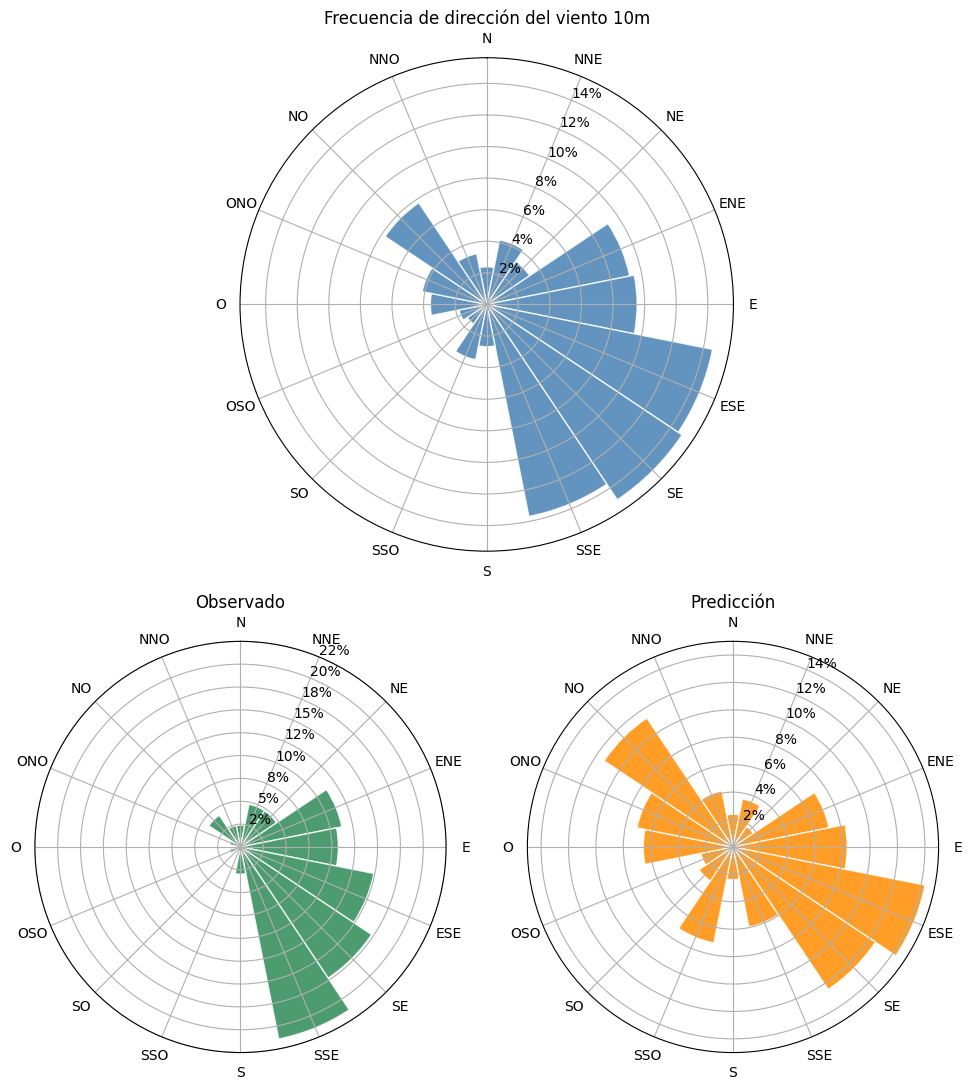

In [ ]:
# Q2 Answer
def rosa_direccion(ax, direccion, titulo, n_sectores=16, color='steelblue'):
    direccion = direccion.dropna()
    ancho = 360 / n_sectores
    dir_desplazada = (direccion + ancho / 2) % 360
    conteos, _ = np.histogram(dir_desplazada, bins=n_sectores, range=(0, 360))
    frecuencia = conteos / conteos.sum() * 100
    angulos = np.deg2rad(np.arange(0, 360, ancho))
    #
    ax.bar(angulos, frecuencia, width=np.deg2rad(ancho), bottom=0,
           color=color, edgecolor='white', alpha=0.85)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    #
    etiquetas = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
                 'S', 'SSO', 'SO', 'OSO', 'O', 'ONO', 'NO', 'NNO']
    ax.set_xticks(angulos)
    ax.set_xticklabels(etiquetas if n_sectores == 16 else [])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_rlabel_position(22.5)
    ax.set_title(titulo, pad=25)

# Plotting wind directions histograms
fig, axs = plt.subplot_mosaic(
    [['general', 'general'],
     ['izq',     'der']],
    figsize=(10, 11),
    height_ratios=[1.2, 1], # Upper row 20% more height
    subplot_kw={'projection': 'polar'}
)
rosa_direccion(axs['general'], hourly_dataframe['wind_direction_10m'], 'Frecuencia de dirección del viento 10m')
rosa_direccion(axs['izq'], df_obs['wind_direction_10m'], 'Observado', color='seagreen')
rosa_direccion(axs['der'], df_prd['wind_direction_10m'], 'Predicción', color='darkorange')
plt.tight_layout()
plt.show()

**Respuesta pregunta 3**

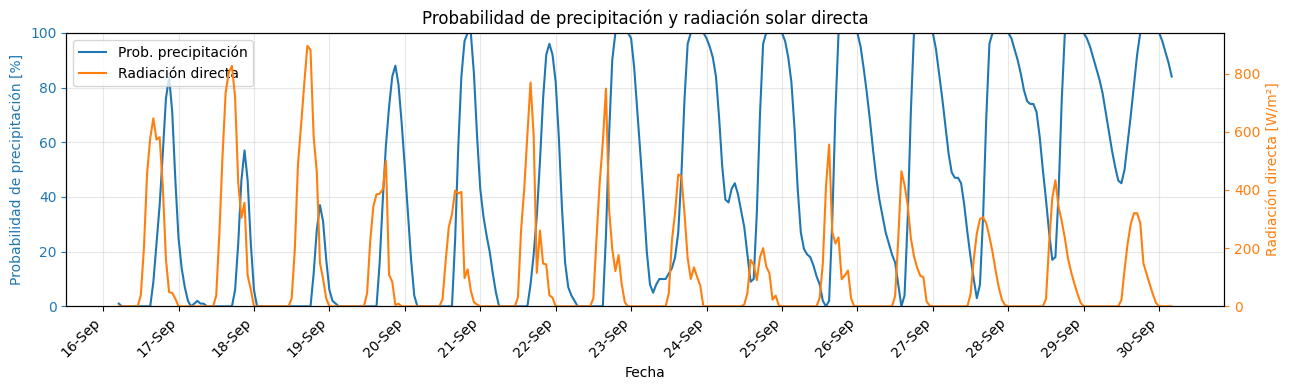

In [ ]:
import matplotlib.dates as mdates

# Var
x    = hourly_dataframe['date']
prob = hourly_dataframe['precipitation_probability']   # %
rad  = hourly_dataframe['direct_radiation']            # W/m²

color_prob = 'tab:blue'
color_rad  = 'tab:orange'

fig, ax1 = plt.subplots(figsize=(13, 4))

# ── 1. Ambas variables en el mismo gráfico (dos ejes Y) ──────────────
ax2 = ax1.twinx()   # segundo eje Y que comparte el eje X

l1, = ax1.plot(x, prob, color=color_prob, linewidth=1.5, label='Prob. precipitación')
l2, = ax2.plot(x, rad, color=color_rad, linewidth=1.5, label='Radiación directa')

# Leyenda única con las dos series (cada eje tiene la suya por separado)
ax1.legend(handles=[l1, l2], loc='upper left')
ax1.set_title('Probabilidad de precipitación y radiación solar directa')

# Formato del eje de fechas
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax1.set_xlabel('Fecha')
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

ax1.set_ylabel('Probabilidad de precipitación [%]', color=color_prob)
ax2.set_ylabel('Radiación directa [W/m²]', color=color_rad)
ax1.tick_params(axis='y', colors=color_prob)
ax2.tick_params(axis='y', colors=color_rad)
ax1.set_ylim(0, 100)
ax2.set_ylim(0, None)

ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()